Epoch 0, Loss: 1.5516146421432495
Epoch 20, Loss: 0.005283193662762642
Epoch 40, Loss: 0.002745805075392127
Epoch 60, Loss: 0.0021915987599641085
Epoch 80, Loss: 0.0018384329741820693
Epoch 100, Loss: 0.001558177056722343
Epoch 120, Loss: 0.001327228150330484
Epoch 140, Loss: 0.00112847238779068
Epoch 160, Loss: 0.0009605655795894563
Epoch 180, Loss: 0.0008181818993762136
Accuracy: 1.0


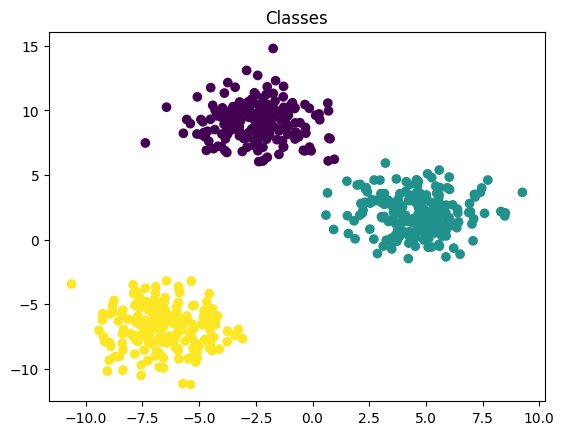

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=600, centers=3, n_features=2,
                 cluster_std=1.5, random_state=42)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

model = nn.Sequential(
    nn.Linear(2, 32), nn.ReLU(),
    nn.Linear(32, 16), nn.ReLU(),
    nn.Linear(16, 3)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    optimizer.zero_grad()
    
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

pred = torch.argmax(y_pred, dim=1)
accuracy = (pred == y).float().mean()

print("Accuracy:", accuracy.item())
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Classes")
plt.show()

##### 1. Observer la loss:
La loss diminue rapidement au cours de lâ€™entraÃ®nement, ce qui montre que le modÃ¨le apprend efficacement Ã  distinguer les diffÃ©rentes classes.
La convergence est plus rapide que pour la classification binaire, car les donnÃ©es sont mieux sÃ©parÃ©es.

Epoch 0, Loss: 0.000697617360856384
Epoch 10, Loss: 0.00064456881955266
Epoch 20, Loss: 0.0005957963294349611
Epoch 30, Loss: 0.0005510828923434019
Epoch 40, Loss: 0.0005100306589156389
Epoch 50, Loss: 0.0004724324680864811
Epoch 60, Loss: 0.0004379912279546261
Epoch 70, Loss: 0.00040643991087563336
Epoch 80, Loss: 0.00037752732168883085
Epoch 90, Loss: 0.00035098090302199125


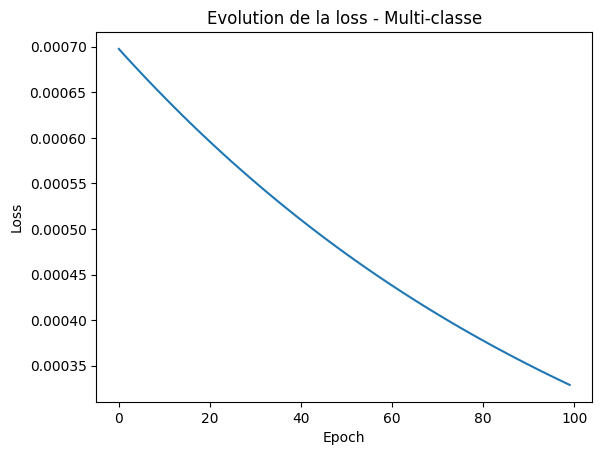

In [2]:
losses = []

for epoch in range(100):
    optimizer.zero_grad()
    
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Evolution de la loss - Multi-classe")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()   


##### 2. Comparaison des performances :
RÃ©gression
La loss (MSE) diminue progressivement
Le modÃ¨le approxime correctement la relation linÃ©aire
Convergence stable et rapide

---->Bonne performance globale

Classification binaire
La loss (BCE) diminue mais plus lentement
Le modÃ¨le apprend une frontiÃ¨re non linÃ©aire
Convergence moins rapide

---->Performance correcte mais problÃ¨me plus difficile

Classification multi-classe
La loss (CrossEntropy) diminue rapidement
Le modÃ¨le sÃ©pare bien les diffÃ©rentes classes
Convergence rapide et stable

---->TrÃ¨s bonne performance

##### 3. Tester d'autres activations:


Epoch 0, Loss: 1.301292061805725
Epoch 20, Loss: 0.04952847957611084
Epoch 40, Loss: 0.01183595322072506
Epoch 60, Loss: 0.00638523930683732
Epoch 80, Loss: 0.004332680720835924
Epoch 100, Loss: 0.0031834577675908804
Epoch 120, Loss: 0.0024536566343158484
Epoch 140, Loss: 0.001966411480680108
Epoch 160, Loss: 0.0016242519486695528
Epoch 180, Loss: 0.0013727416517212987
Accuracy: 1.0
100


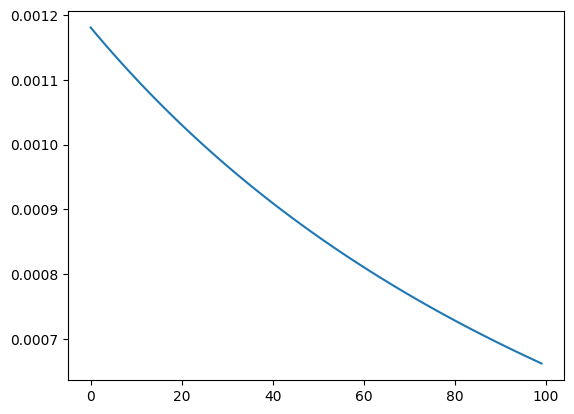

In [3]:
model = nn.Sequential(
    nn.Linear(2, 32), nn.Tanh(),
    nn.Linear(32, 16), nn.Tanh(),
    nn.Linear(16, 3)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    optimizer.zero_grad()
    
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

pred = torch.argmax(y_pred, dim=1)
accuracy = (pred == y).float().mean()

print("Accuracy:", accuracy.item())
losses = []
for epoch in range(100):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
print(len(losses))  
plt.plot(losses)
plt.show()

Epoch 0, Loss: 1.0866092443466187
Epoch 20, Loss: 0.3002927601337433
Epoch 40, Loss: 0.052962832152843475
Epoch 60, Loss: 0.020911935716867447
Epoch 80, Loss: 0.013077646493911743
Epoch 100, Loss: 0.009600329212844372
Epoch 120, Loss: 0.0075170723721385
Epoch 140, Loss: 0.006102044600993395
Epoch 160, Loss: 0.005079102702438831
Epoch 180, Loss: 0.004309547133743763
Accuracy: 1.0
100


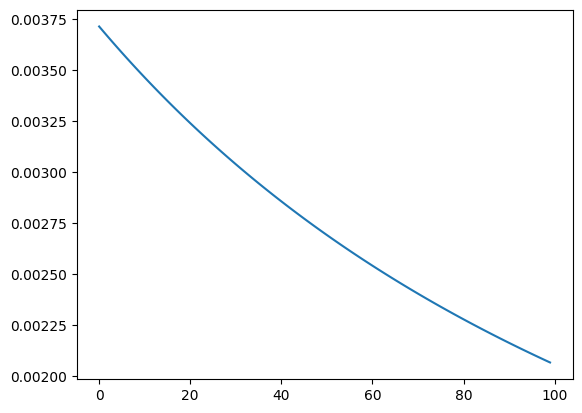

In [4]:
model = nn.Sequential(
    nn.Linear(2, 32), nn.Sigmoid(),
    nn.Linear(32, 16), nn.Sigmoid(),
    nn.Linear(16, 3)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    optimizer.zero_grad()
    
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

pred = torch.argmax(y_pred, dim=1)
accuracy = (pred == y).float().mean()

print("Accuracy:", accuracy.item())
losses = []
for epoch in range(100):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
print(len(losses))  
plt.plot(losses)
plt.show()

Avec ReLU, la loss diminue rapidement et atteint une valeur faible, ce qui indique une convergence rapide et efficace.
Avec Tanh, la convergence est correcte mais plus lente que ReLU.
Avec Sigmoid, la diminution de la loss est plus lente et la performance finale est moins bonne.

ReLU est la fonction d'activation la plus efficace, tandis que Sigmoid est moins adaptée .

##### 4. Modifier le learning rate:


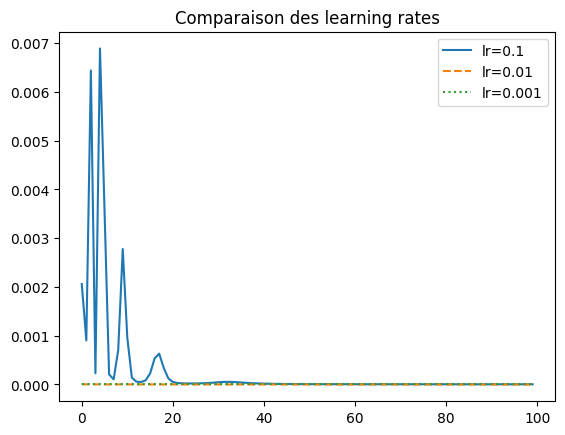

In [5]:
losses_lr1 = []

optimizer = optim.Adam(model.parameters(), lr=0.1)

for epoch in range(100):
    optimizer.zero_grad()
    
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    loss.backward()
    optimizer.step()

    losses_lr1.append(loss.item())

losses_lr2 = []

optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    loss.backward()
    optimizer.step()

    losses_lr2.append(loss.item())

losses_lr3 = []

optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
    optimizer.zero_grad()
    
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    loss.backward()
    optimizer.step()
    losses_lr3.append(loss.item())

import matplotlib.pyplot as plt

plt.plot(losses_lr1, label="lr=0.1")
plt.plot(losses_lr2, '--', label="lr=0.01")  # pointillÃ©
plt.plot(losses_lr3, ':', label="lr=0.001")  # pointillÃ© diffÃ©rent
plt.legend()
plt.title("Comparaison des learning rates")
plt.show()

- La courbe lr=0.1 diminue vite au début, mais elle peut devenir moins stable (oscillations possibles) car le pas d'apprentissage est grand.
- La courbe lr=0.01 est en general le meilleur compromis : convergence rapide et trajectoire plus reguliere.
- La courbe lr=0.001 est la plus stable, mais elle converge plus lentement : la loss reste plus elevee pendant plus d'epochs.
- Conclusion: sur ce jeu de donnees, lr=0.01 semble le plus adapte pour obtenir une bonne convergence sans instabilite.